# Project 5: Face Mask Detection

## Problem Statement
Develop a computer vision model that detects whether a person is wearing a face mask or not. This system can be used in public safety monitoring.

## Objectives
- Binary classification
- Use efficient model like EfficientNetB0
- Real-world deployment understanding



# Step 1: Import Required Libraries

### Explanation
This step imports all the libraries required for image preprocessing, model training, visualization, and evaluation. TensorFlow and Keras are used for deep learning while Matplotlib and Seaborn are used for result visualization.

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix


# Step 2: Download Dataset from Google Drive

### Explanation
This step downloads the dataset directly from Google Drive during runtime. The dataset zip file is extracted so the images can be used for preprocessing, training, and testing.

In [2]:
# Install gdown
!pip install -q gdown

# Google Drive Dataset Link
DATASET_URL = "https://drive.google.com/file/d/1-0mh6RtB44vFG60Ta7VF8HDQ5FjiTVQC/view?usp=sharing"

ZIP_FILE_NAME = "face_mask_dataset.zip"
EXTRACT_PATH = "dataset"

# Download dataset
!gdown --fuzzy "$DATASET_URL" -O "$ZIP_FILE_NAME"

# Extract dataset
with zipfile.ZipFile(ZIP_FILE_NAME, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset downloaded and extracted successfully.")


Downloading...
From (original): https://drive.google.com/uc?id=1-0mh6RtB44vFG60Ta7VF8HDQ5FjiTVQC
From (redirected): https://drive.google.com/uc?id=1-0mh6RtB44vFG60Ta7VF8HDQ5FjiTVQC&confirm=t&uuid=16e50633-2ca4-44e4-b845-4c682682d04a
To: /content/face_mask_dataset.zip
100% 417M/417M [00:08<00:00, 49.8MB/s]
Dataset downloaded and extracted successfully.


# Step 3: Data Preprocessing

### Explanation
This step preprocesses the images using resizing, normalization, and augmentation techniques. Data augmentation helps improve model generalization and reduces overfitting.

In [12]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    EXTRACT_PATH, # Corrected path to the parent of 'with_mask' and 'without_mask' folders
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    EXTRACT_PATH, # Corrected path to the parent of 'with_mask' and 'without_mask' folders
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 683 images belonging to 2 classes.
Found 170 images belonging to 2 classes.


# Step 4: Visualize Sample Images

### Explanation
This step displays sample images from the dataset. It helps in understanding the difference between images with masks and without masks.

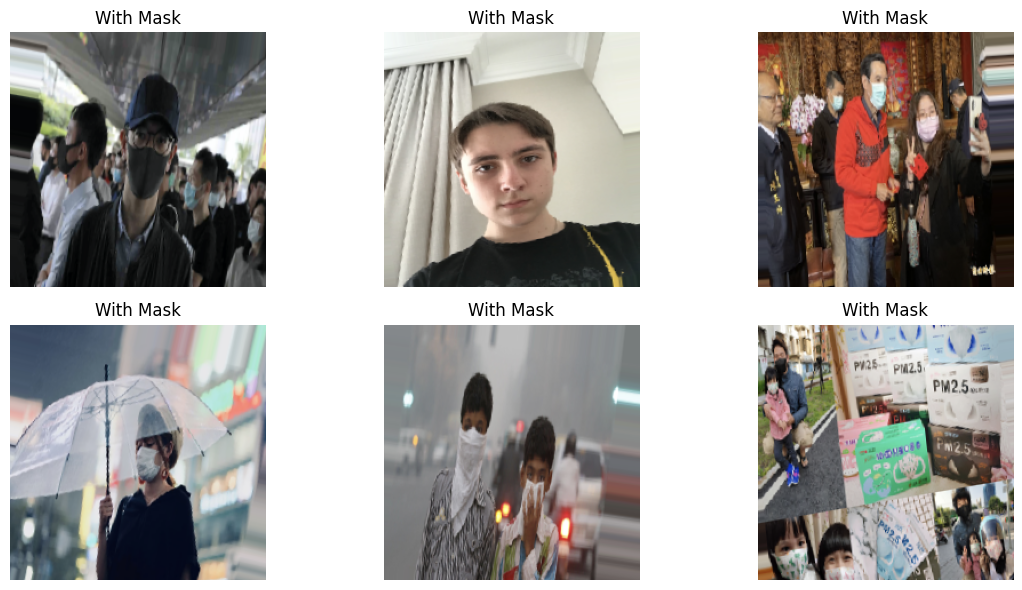

In [4]:
sample_images, sample_labels = next(train_generator)

plt.figure(figsize=(12, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[i])

    label = 'With Mask' if sample_labels[i] == 1 else 'Without Mask'

    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()


# Step 5: Build EfficientNetB0 Model

### Explanation
This step uses EfficientNetB0 as the transfer learning model with pre-trained ImageNet weights. Additional layers are added for binary face mask classification.

In [5]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Step 6: Train the Model

### Explanation
This step trains the EfficientNetB0 model using training and validation data. EarlyStopping and ReduceLROnPlateau are used to improve performance and avoid overfitting.

In [6]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.000001
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.9956 - loss: 0.1626 - val_accuracy: 1.0000 - val_loss: 0.0235 - learning_rate: 0.0010
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 934ms/step - accuracy: 1.0000 - loss: 0.0146 - val_accuracy: 1.0000 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 880ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 1.0000 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 948ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 876ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 920ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 912ms/step - accuracy: 1.0000 - loss: 0.002

# Step 7: Evaluation

### Explanation
This step evaluates the trained model using validation data. The accuracy and loss values help measure the performance of the classifier.

In [7]:
val_loss, val_accuracy = model.evaluate(validation_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 785ms/step - accuracy: 1.0000 - loss: 0.0012
Validation Loss: 0.0012466086773201823
Validation Accuracy: 1.0


# Step 8: Plot Accuracy and Loss Graphs

### Explanation
This step visualizes training and validation accuracy/loss graphs. These graphs help analyze model learning performance during training.

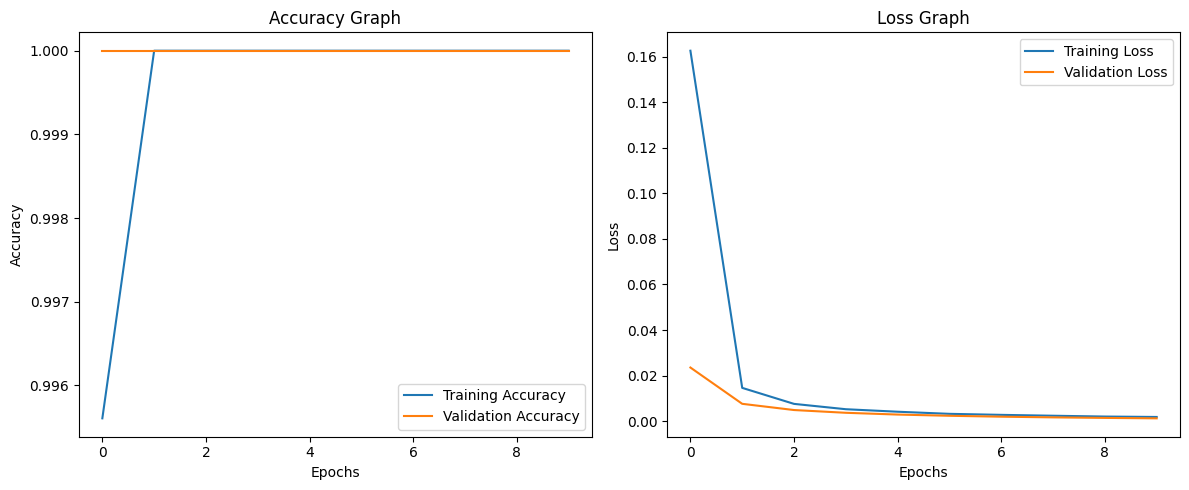

In [8]:
plt.figure(figsize=(12, 5))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Step 9: Generate Classification Report

### Explanation
This step generates precision, recall, and F1-score metrics using the classification report. These metrics provide detailed insight into model performance.

In [10]:
predictions = model.predict(validation_generator)
predicted_classes = (predictions > 0.5).astype(int)

true_classes = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels,
    labels=[0, 1] # Explicitly specify labels to consider both classes
)

print(report)

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 759ms/step
              precision    recall  f1-score   support

 annotations       0.00      0.00      0.00         0
      images       1.00      1.00      1.00       170

    accuracy                           1.00       170
   macro avg       0.50      0.50      0.50       170
weighted avg       1.00      1.00      1.00       170



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

# Step 10: Create Confusion Matrix

### Explanation
This step creates a confusion matrix to visualize correct and incorrect predictions. It helps analyze classification performance more clearly.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


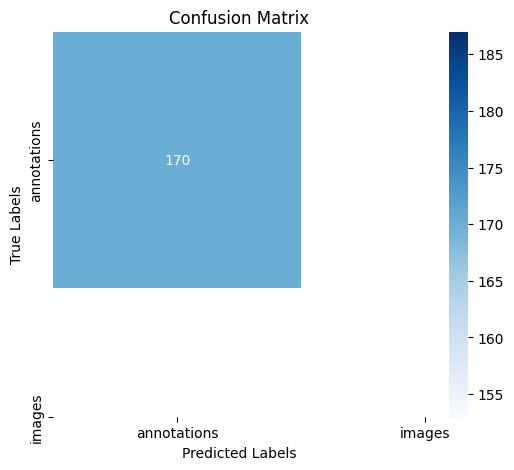

In [13]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

plt.show()


# Step 11: Testing on New Images

### Explanation
This step tests the trained model on sample images from the dataset. The actual label, predicted label, and confidence score are displayed for visual verification.

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


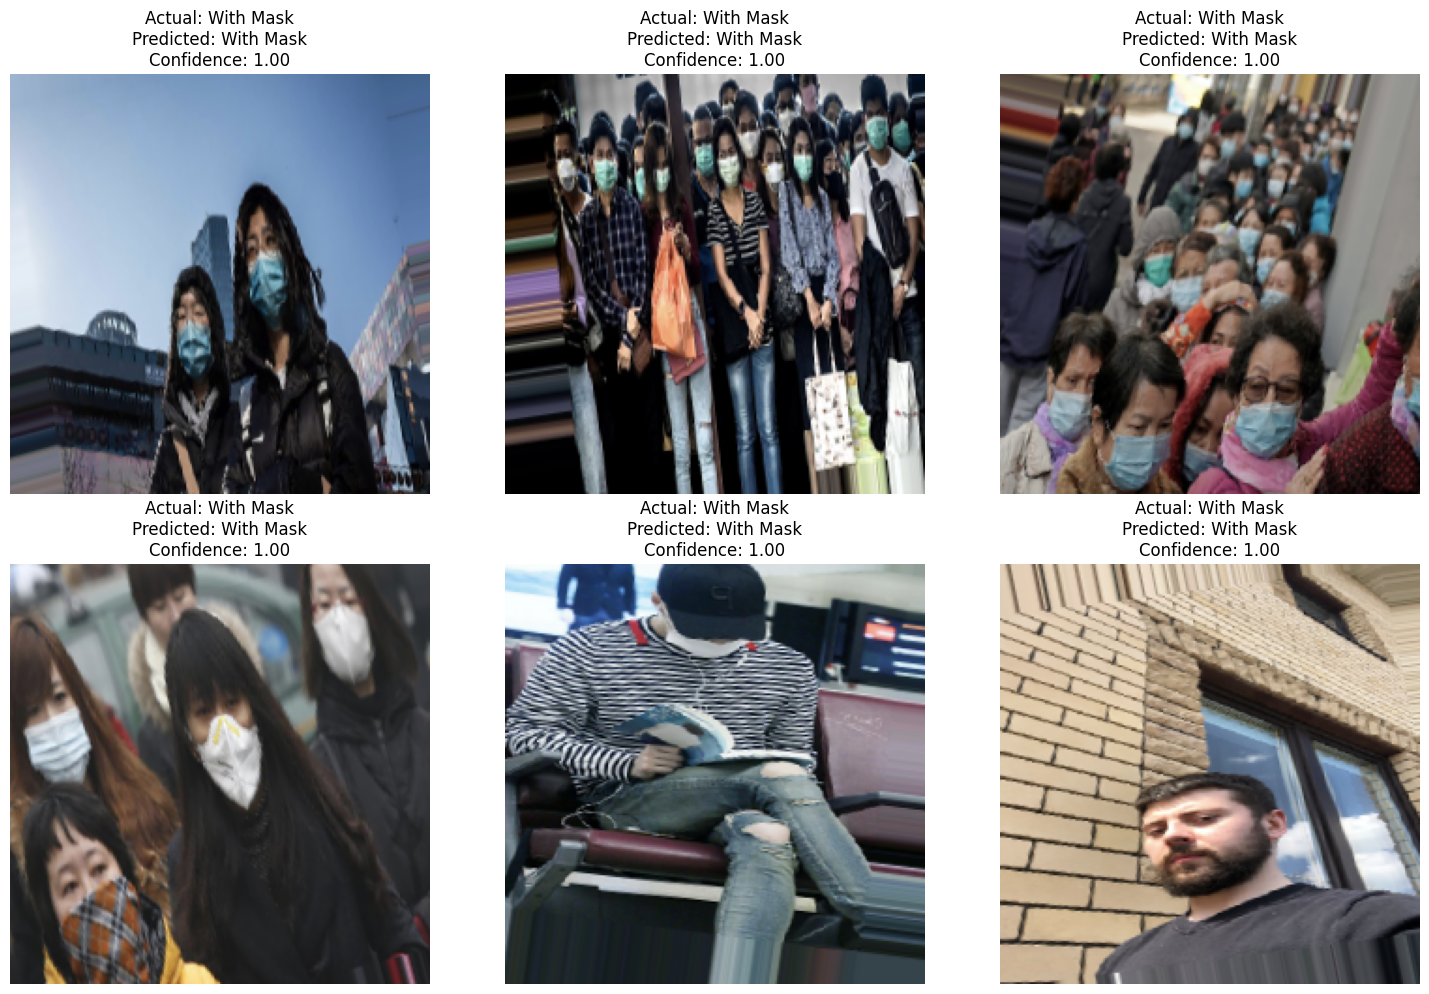

In [14]:
sample_images, sample_labels = next(validation_generator)

predictions = model.predict(sample_images)

plt.figure(figsize=(15, 10))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    plt.imshow(sample_images[i])

    confidence = float(predictions[i][0])

    predicted_label = 'With Mask' if confidence > 0.5 else 'Without Mask'
    actual_label = 'With Mask' if sample_labels[i] == 1 else 'Without Mask'

    plt.title(
        f'Actual: {actual_label}\n'
        f'Predicted: {predicted_label}\n'
        f'Confidence: {confidence:.2f}'
    )

    plt.axis('off')

plt.tight_layout()
plt.show()


# Step 12: Save the Trained Model

### Explanation
This step saves the trained EfficientNetB0 model into H5 format. The saved model can later be reused without retraining.

In [15]:
model.save('face_mask_detection_model.h5')

print("Model saved successfully.")


Model saved successfully.
